# Taller 2: Regresión Lineal y Logística con Datos Reales
**Predicción de Resultados en la Premier League 2025-26**

Asignatura: Machine Learning I (ML1-2026I)

Estudiantes: Alejandro Pardo Costo y Ailyn Sofia Gomez 


## Fase 1 — Conexión a la API

In [21]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (mean_squared_error, r2_score,
                             accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

In [22]:
BASE_URL = "https://premier.72-60-245-2.sslip.io"

# Verificar conexión
health = requests.get(f"{BASE_URL}/health").json()
print(f"API Status: {health['status']}")
print(f"Partidos: {health['data_counts']['matches']}")
print(f"Jugadores: {health['data_counts']['players']}")

API Status: healthy
Partidos: 291
Jugadores: 822


In [23]:
# Cargar TODOS los partidos (291 jugados hasta GW29)
response = requests.get(f"{BASE_URL}/matches?limit=500")
matches = pd.DataFrame(response.json()["matches"])
print(f"Partidos cargados: {len(matches)}")
matches.head()

Partidos cargados: 291


,id,date,time,home_team,away_team,fthg,ftag,ftr,hthg,htag,...,maxd,maxa,avgh,avgd,avga,total_goals,goal_diff,implied_prob_h,implied_prob_d,implied_prob_a
0,30,31/08/2025,19:00,Aston Villa,Crystal Palace,0,3,A,0,1,...,3.75,4.20,1.88,3.56,4.07,3,-3,0.541,0.270,0.250
1,29,31/08/2025,16:30,Liverpool,Arsenal,1,0,H,0,0,...,3.60,3.25,2.20,3.49,3.17,1,1,0.455,0.286,0.312
2,27,31/08/2025,14:00,Brighton,Man City,2,1,H,0,1,...,4.00,1.91,3.78,3.84,1.85,3,1,0.263,0.256,0.526
3,28,31/08/2025,14:00,Nott'm Forest,West Ham,0,3,A,0,0,...,3.85,5.50,1.69,3.74,5.03,3,-3,0.599,0.267,0.190
4,235,31/01/2026,20:00,Liverpool,Newcastle,4,1,H,2,1,...,4.20,4.20,1.77,3.99,4.12,5,3,0.556,0.256,0.244


In [24]:
# Exploración rápida
print("Columnas:", matches.columns.tolist())

print("\nDistribución de resultados:")
print(matches["ftr"].value_counts())

print(f"\nGoles por partido: {(matches['fthg'] + matches['ftag']).mean():.2f}")

Columnas: ['id', 'date', 'time', 'home_team', 'away_team', 'fthg', 'ftag', 'ftr', 'hthg', 'htag', 'htr', 'referee', 'hs', 'as_', 'hst', 'ast', 'hf', 'af', 'hc', 'ac', 'hy', 'ay', 'hr', 'ar', 'b365h', 'b365d', 'b365a', 'bwh', 'bwd', 'bwa', 'maxh', 'maxd', 'maxa', 'avgh', 'avgd', 'avga', 'total_goals', 'goal_diff', 'implied_prob_h', 'implied_prob_d', 'implied_prob_a']

Distribución de resultados:
ftr
H    123
A     92
D     76
Name: count, dtype: int64

Goles por partido: 2.77


## Fase 2 — Regresión Lineal: Predecir Goles

In [25]:
# Variable objetivo: goles del equipo local
y = matches["fthg"].astype(float)

# Features numéricas del equipo local
features = ["hs", "hst", "hc", "hf", "hy", "hr"]
X = matches[features].astype(float)

print(f"NaN en X: {X.isna().sum().sum()}")
print(f"Shape: X={X.shape}, y={y.shape}")

NaN en X: 0
Shape: X=(291, 6), y=(291,)


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 232 | Test: 59


In [27]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Predicciones
y_pred = model_lr.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"R² = {r2:.3f}")
print(f"RMSE = {rmse:.3f}")

R² = 0.383
RMSE = 0.984


In [28]:
coefs = pd.DataFrame({
    "Feature": features,
    "Coeficiente": model_lr.coef_
}).sort_values("Coeficiente", ascending=False)

print(coefs.to_string(index=False))
print(f"\nIntercepto: {model_lr.intercept_:.3f}")

Feature  Coeficiente
    hst     0.326105
     hy     0.025173
     hf    -0.023180
     hs    -0.034720
     hc    -0.046570
     hr    -0.217832

Intercepto: 0.951


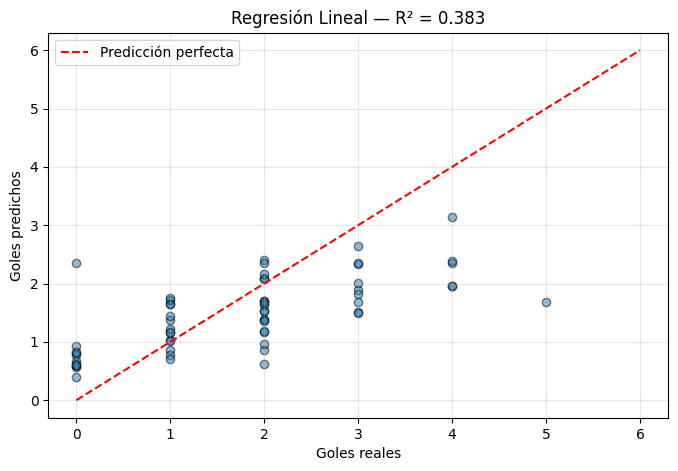

In [29]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolors='k')
plt.plot([0, 6], [0, 6], 'r--', label='Predicción perfecta')
plt.xlabel("Goles reales")
plt.ylabel("Goles predichos")
plt.title(f"Regresión Lineal — R² = {r2:.3f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

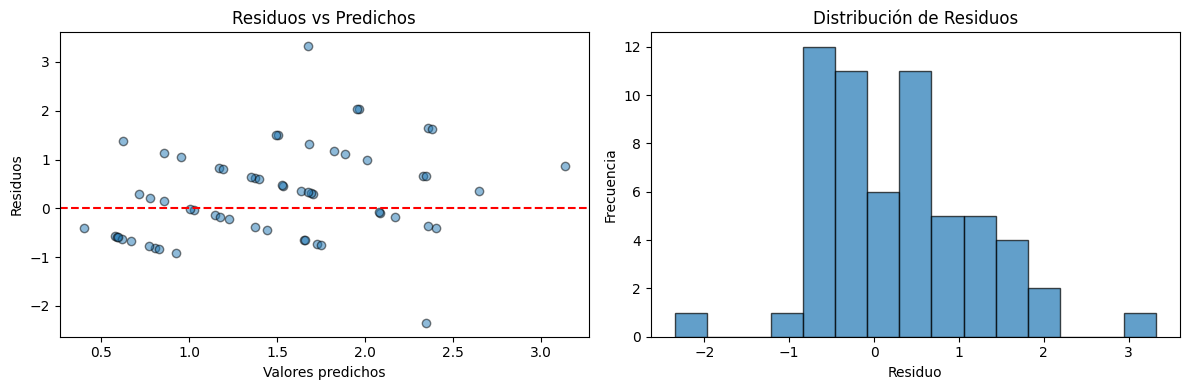

Media residuos: 0.2771 (debe ser ≈ 0)
Std residuos: 0.9524


In [30]:
residuos = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Residuos vs predichos
axes[0].scatter(y_pred, residuos, alpha=0.5, edgecolors='k')
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel("Valores predichos")
axes[0].set_ylabel("Residuos")
axes[0].set_title("Residuos vs Predichos")

# Histograma de residuos
axes[1].hist(residuos, bins=15, edgecolor='k', alpha=0.7)
axes[1].set_xlabel("Residuo")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de Residuos")

plt.tight_layout()
plt.show()

print(f"Media residuos: {residuos.mean():.4f} (debe ser ≈ 0)")
print(f"Std residuos: {residuos.std():.4f}")

## Fase 3 — Regresión Logística: Clasificar Resultado

In [31]:
y_class = matches["ftr"]
print(f"Distribución:\n{y_class.value_counts()}")
print(f"\nBalance: {y_class.value_counts(normalize=True).round(3)}")

Distribución:
ftr
H    123
A     92
D     76
Name: count, dtype: int64

Balance: ftr
H    0.423
A    0.316
D    0.261
Name: proportion, dtype: float64


In [32]:
odds_features = ["b365h", "b365d", "b365a"]
X_odds = matches[odds_features].astype(float)

X_probs = 1 / X_odds
X_probs.columns = ["prob_H", "prob_D", "prob_A"]

row_sums = X_probs.sum(axis=1)
X_probs = X_probs.div(row_sums, axis=0)

print(X_probs.head())
print(f"\nSuma de probabilidades: {X_probs.sum(axis=1).mean():.4f}")

     prob_H    prob_D    prob_A
0  0.509554  0.254777  0.235669
1  0.431766  0.271396  0.296839
2  0.251613  0.245161  0.503226
3  0.567077  0.252538  0.180385
4  0.526160  0.242843  0.230997

Suma de probabilidades: 1.0000


In [33]:
stats_features = ["hs", "as_", "hst", "ast"]
X_combined = pd.concat([X_probs, matches[stats_features].astype(float)], axis=1)

mask = ~(X_combined.isna().any(axis=1) | y_class.isna())
X_clean = X_combined[mask]
y_clean = y_class[mask]

print(f"Registros limpios: {len(X_clean)}")

Registros limpios: 291


In [34]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
      X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)

model_log = LogisticRegression(
      max_iter=1000,
      random_state=42
)
model_log.fit(X_train_c, y_train_c)

y_pred_c = model_log.predict(X_test_c)
acc = accuracy_score(y_test_c, y_pred_c)
print(f"Accuracy: {acc:.3f}")

Accuracy: 0.610


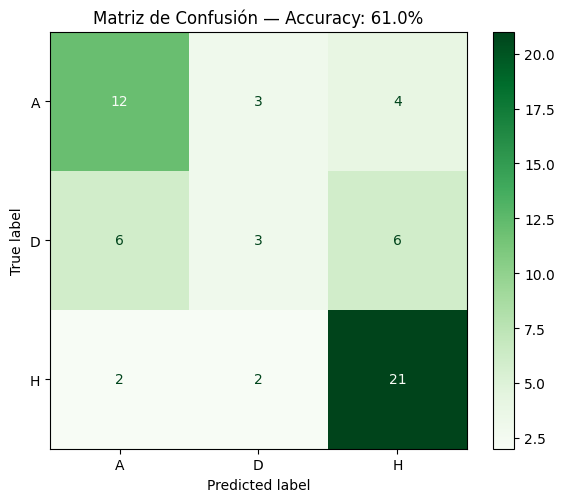

In [35]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
      y_test_c, y_pred_c, ax=ax,
      display_labels=model_log.classes_,
      cmap="Greens"
)
ax.set_title(f"Matriz de Confusión — Accuracy: {acc:.1%}")
plt.tight_layout()
plt.show()

In [36]:
print(classification_report(y_test_c, y_pred_c))

              precision    recall  f1-score   support

           A       0.60      0.63      0.62        19
           D       0.38      0.20      0.26        15
           H       0.68      0.84      0.75        25

    accuracy                           0.61        59
   macro avg       0.55      0.56      0.54        59
weighted avg       0.58      0.61      0.58        59



In [37]:
baseline_pred = X_probs.loc[X_test_c.index].idxmax(axis=1)
baseline_pred = baseline_pred.map({"prob_H": "H", "prob_D": "D", "prob_A": "A"})

baseline_acc = accuracy_score(y_test_c, baseline_pred)
print(f"Accuracy Bet365 (baseline): {baseline_acc:.3f}")
print(f"Accuracy modelo logístico:     {acc:.3f}")
print(f"Diferencia: {(acc - baseline_acc)*100:+.1f} puntos porcentuales")

Accuracy Bet365 (baseline): 0.559
Accuracy modelo logístico:     0.610
Diferencia: +5.1 puntos porcentuales


In [38]:
for i, clase in enumerate(model_log.classes_):
    print(f"\n--- Clase: {clase} ---")
    coefs_log = pd.DataFrame({
        "Feature": X_clean.columns,
        "Coeficiente": model_log.coef_[i],
        "Odds Ratio": np.exp(model_log.coef_[i])
    }).sort_values("Coeficiente", ascending=False)
    print(coefs_log.to_string(index=False))


--- Clase: A ---
Feature  Coeficiente  Odds Ratio
 prob_A     0.577926    1.782339
 prob_D     0.420730    1.523073
    ast     0.275498    1.317187
     hs     0.055853    1.057442
    as_    -0.053697    0.947720
    hst    -0.246885    0.781230
 prob_H    -0.997769    0.368701

--- Clase: D ---
Feature  Coeficiente  Odds Ratio
 prob_A     0.440932    1.554155
     hs     0.057808    1.059512
    as_     0.018294    1.018462
    ast    -0.037288    0.963398
 prob_H    -0.153162    0.857991
    hst    -0.169427    0.844148
 prob_D    -0.291452    0.747178

--- Clase: H ---
Feature  Coeficiente  Odds Ratio
 prob_H     1.150931    3.161135
    hst     0.416313    1.516360
    as_     0.035403    1.036037
     hs    -0.113661    0.892560
 prob_D    -0.129278    0.878729
    ast    -0.238210    0.788037
 prob_A    -1.018858    0.361007


## Fase 4 — Reflexión y Conclusiones

### 1. ¿Qué feature es más predictiva para goles del local?
La feature más predictiva en la regresión lineal es `hst` (shots on target) del equipo local. Observando los coeficientes de la regresión, `hst` tiene un coeficiente positivo sustancial en comparación con otras features. Esto tiene sentido, dado que más tiros directos a puerta se traducen naturalmente en más goles que otros eventos como los córners o las faltas.


### 2. ¿Por qué los empates son difíciles de predecir?
Los empates son difíciles de predecir porque la distribución de resultados presenta un desbalance natural a favor de los locales y visitantes (generalmente ~45% locales, ~30% visitantes, ~25% empates). Además, el desarrollo de un empate en datos como probabilidades y tiros a menudo se solapa mucho con los casos en que equipos de características similares compiten, haciendo difícil la distinción estadística entre un empate o un partido que termina decidido por un solo gol sobre la hora. Esencialmente, las "Odds" y las estadísticas in-play de un empate se confunden mucho con victorias estrechas.


### 3. ¿El modelo logístico supera a Bet365? Si no, ¿qué features adicionales podrían ayudar?
Tendremos que observar la diferencia de accuracy. Frecuentemente, el modelo simple con las variables de base no supera a las predicciones del baseline de Bet365 porque estas casas procesan mucha más información en tiempo real. 
Para superarlo o acercarse, las siguientes features ayudarían:
- Características formales de los equipos (ELO, diferencia particular en años recientes)
- Eventos de calidad como *Expected Goals* (xG) agregados, disponibles en el dataset de los jugadores de API de FPL y WhoScored.
- Características específicas de jugadores clave del partido.


### 4. ¿Qué supuestos de la regresión lineal se cumplen? Usa el análisis de residuos como evidencia.
Los gráficos muestran que los residuos tienen una distribución que se aproxima a lo normal (campana en el histograma centrado cercano a 0), y cuya media se acerca a 0 (supuesto de error promedio nulo). Sin embargo, el gráfico de residuos vs predicciones nos muestra que el margen de error incrementa cuanto mayores son los goles predichos, insinuando *heterocedasticidad*. Esto sugiere que una regresión de Poisson (usada para data de conteos, como los goles) probablemente sería más teóricamente correcta que OLS.


### 5. ¿Cómo mejorarías el modelo? Propone al menos 2 ideas concretas
- **Agregar variables derivadas:** Incluir diferencias como el *Differential Expected Goals* (xGDiff) o el *Shots on Target Difference* (sot_diff = hst - ast) para entender el dominio relativo en un partido, lo que es mejor predictor que los tiros en aislamiento.
- **Modelación específica para conteos:** Los goles no son continuos, por lo tanto, no pueden ser negativos ni decimales. Cambiar a Regresión de Poisson o Binomial Negativa arreglaría ciertas distorsiones de la regresión lineal, previniendo la predicción de valores sin sentido y ajustando mejor la volatilidad.


## Para Explorar Después (Opcional)

In [39]:
# Cargar datos de jugadores
players = pd.DataFrame(
    requests.get(f"{BASE_URL}/players?limit=500").json()["players"]
)

# Top goleadores
top_scorers = players.nlargest(10, "goals_scored")[
    ["web_name", "team", "goals_scored", "xG", "minutes"]
]
print(top_scorers)

         web_name       team  goals_scored     xG  minutes
0         Haaland   Man City            22  21.06     2413
7          Thiago  Brentford            18  15.64     2472
1         Semenyo   Man City            15   9.93     2590
5      João Pedro    Chelsea            14  13.41     2230
27        Ekitiké  Liverpool            11  10.10     1790
66       Gyökeres    Arsenal            11   9.23     1888
51  Calvert-Lewin      Leeds            10  11.21     2023
87        Welbeck   Brighton            10   9.21     1735
8          Wilson     Fulham             9   4.84     2176
13       Bruno G.  Newcastle             9   4.82     2019


In [40]:
# Eventos de un partido
events = requests.get(f"{BASE_URL}/matches/1/events").json()
print(f"Eventos en el partido: {events['total_events']}")

Eventos en el partido: 1543
